# 01 — Exploratory Data Analysis
## AI-Based Predictive Maintenance System
**Dataset:** UCI AI4I 2020 Predictive Maintenance  
**Target:** `Machine failure`  

> This notebook explores the raw dataset. All analysis is read-only — the original CSV is never modified.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Consistent figure style
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

RAW_PATH = os.path.join('..', 'data', 'raw', 'ai4i2020.csv')
print('Dataset path:', os.path.abspath(RAW_PATH))

Dataset path: /Users/piyushmaity/Documents/predictive_maintanance/data/raw/ai4i2020.csv


---
## 1. Load the Dataset

In [2]:
if not os.path.exists(RAW_PATH):
    raise FileNotFoundError(
        'Dataset not found.\n'
        'Download it from https://archive.ics.uci.edu/dataset/601/'
        'ai4i+2020+predictive+maintenance+dataset\n'
        'and place it at: data/raw/ai4i2020.csv'
    )

df = pd.read_csv(RAW_PATH)
print('Dataset loaded successfully.')

Dataset loaded successfully.


---
## 2. Basic Data Understanding

In [3]:
print('Shape:', df.shape)
df.head()

Shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
print('Column names:')
for col in df.columns:
    print(' ', col)

Column names:
  UDI
  Product ID
  Type
  Air temperature [K]
  Process temperature [K]
  Rotational speed [rpm]
  Torque [Nm]
  Tool wear [min]
  Machine failure
  TWF
  HDF
  PWF
  OSF
  RNF


In [5]:
print('Data types:')
print(df.dtypes)

Data types:
UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object


In [6]:
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


In [7]:
print('Duplicate rows:', df.duplicated().sum())

Duplicate rows: 0


In [8]:
print('Descriptive statistics:')
df.describe()

Descriptive statistics:


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


---
## 3. Target Variable: Machine Failure

In [9]:
failure_counts = df['Machine failure'].value_counts()
print('Machine failure distribution:')
print(failure_counts)
print(f'\nFailure rate: {df["Machine failure"].mean()*100:.2f}%')

Machine failure distribution:
Machine failure
0    9661
1     339
Name: count, dtype: int64

Failure rate: 3.39%


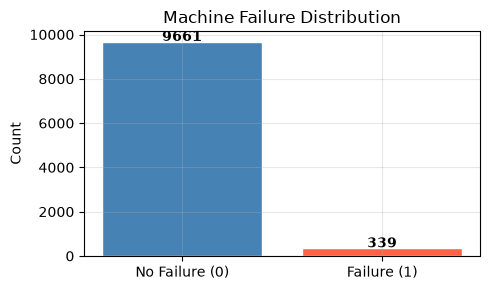

In [10]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(['No Failure (0)', 'Failure (1)'], failure_counts.values,
       color=['steelblue', 'tomato'], edgecolor='white')
ax.set_title('Machine Failure Distribution')
ax.set_ylabel('Count')
for i, v in enumerate(failure_counts.values):
    ax.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Feature Distributions

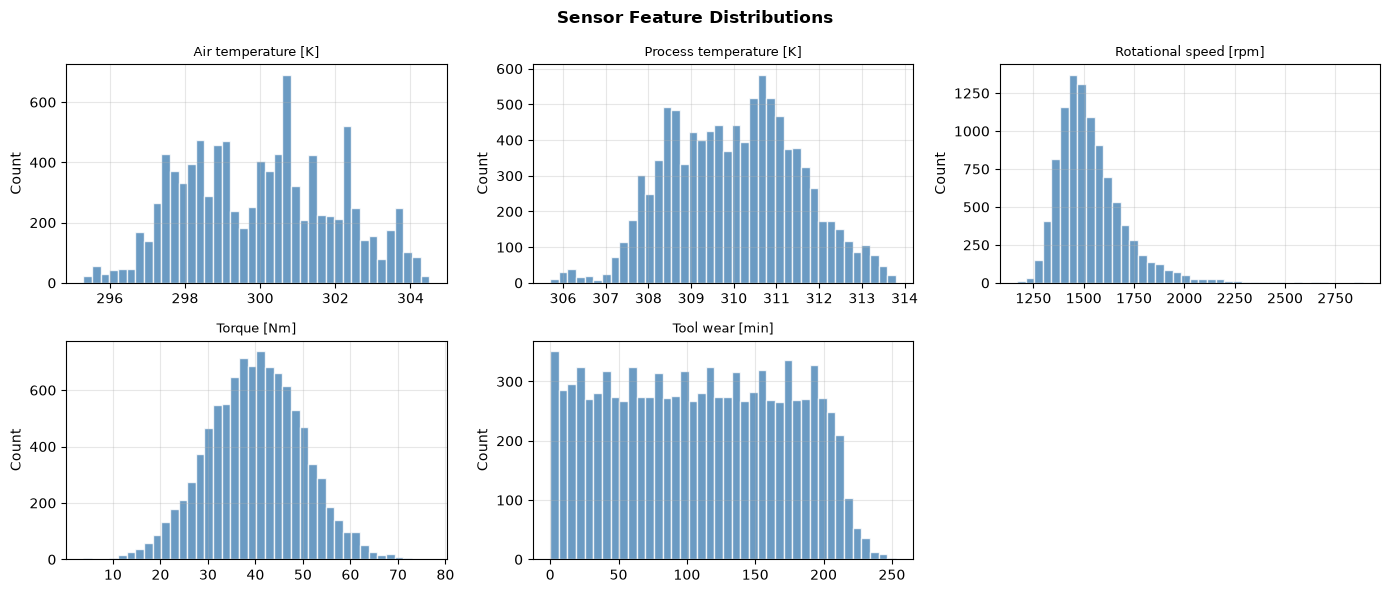

In [11]:
sensor_cols = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]',
]

fig, axes = plt.subplots(2, 3, figsize=(14, 6))
axes = axes.flatten()

for i, col in enumerate(sensor_cols):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_ylabel('Count')

# Hide unused subplot
axes[-1].set_visible(False)
plt.suptitle('Sensor Feature Distributions', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Sensor Values by Failure Class

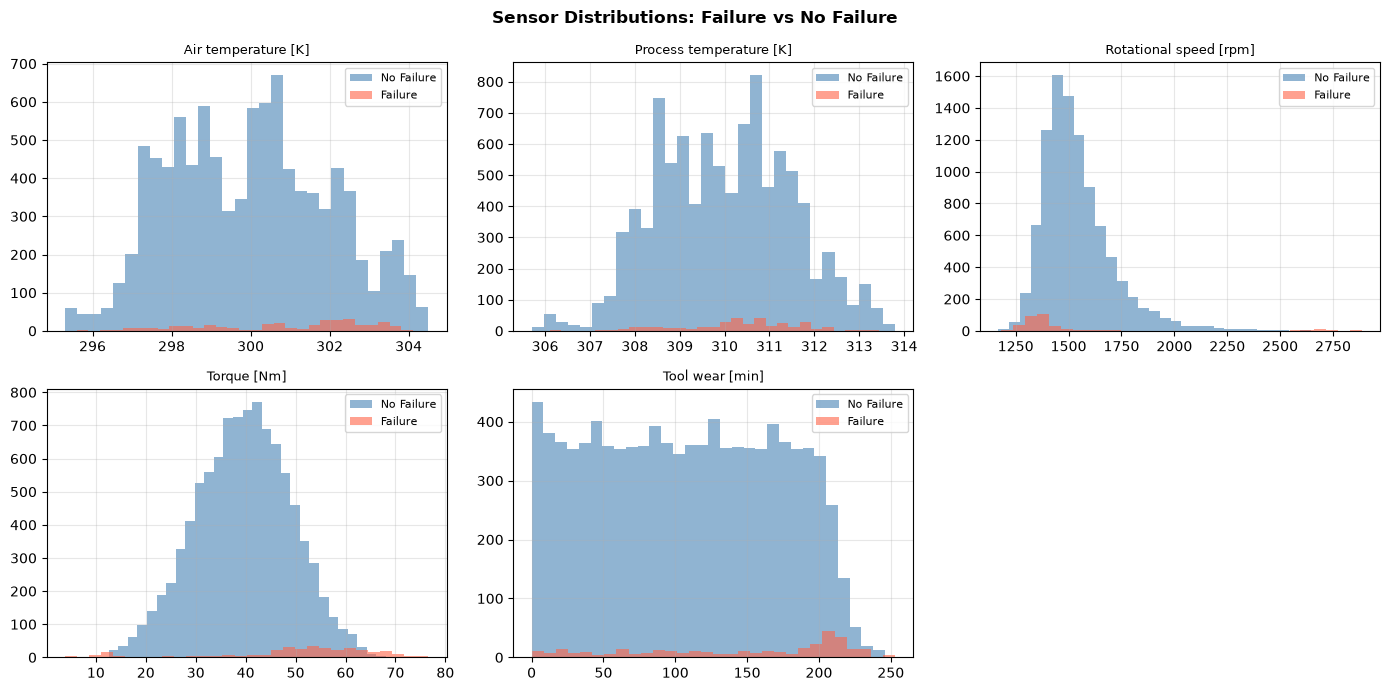

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, col in enumerate(sensor_cols):
    for label, color in [(0, 'steelblue'), (1, 'tomato')]:
        subset = df[df['Machine failure'] == label][col]
        axes[i].hist(subset, bins=30, alpha=0.6, color=color,
                     label='No Failure' if label == 0 else 'Failure')
    axes[i].set_title(col, fontsize=9)
    axes[i].legend(fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Sensor Distributions: Failure vs No Failure', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Machine Type vs Failure Rate

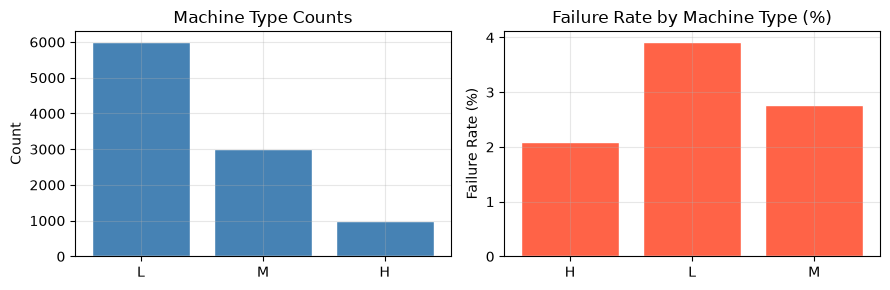

Failure rate by type (%):
Type
H    2.09
L    3.92
M    2.77
Name: Machine failure, dtype: float64


In [13]:
type_failure = df.groupby('Type')['Machine failure'].mean() * 100
type_counts  = df['Type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(9, 3))

axes[0].bar(type_counts.index, type_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Machine Type Counts')
axes[0].set_ylabel('Count')

axes[1].bar(type_failure.index, type_failure.values, color='tomato', edgecolor='white')
axes[1].set_title('Failure Rate by Machine Type (%)')
axes[1].set_ylabel('Failure Rate (%)')

plt.tight_layout()
plt.show()

print('Failure rate by type (%):')
print(type_failure.round(2))

---
## 7. Correlation Heatmap

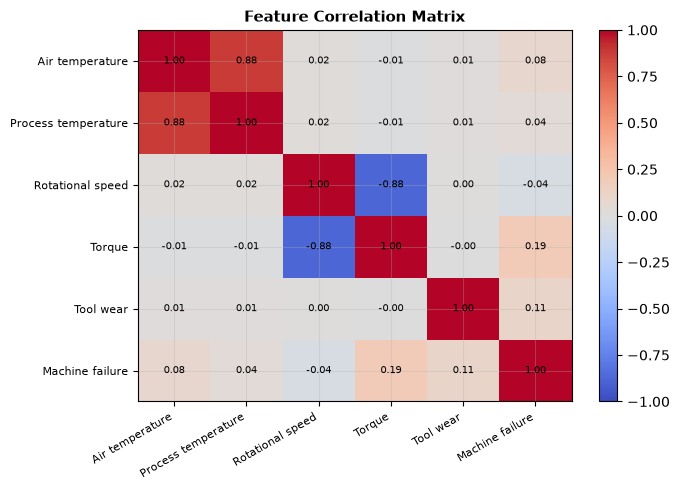

In [14]:
numeric_cols = sensor_cols + ['Machine failure']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax)

labels = [c.replace(' [K]', '').replace(' [rpm]', '').replace(' [Nm]', '').replace(' [min]', '')
          for c in numeric_cols]
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
ax.set_yticklabels(labels, fontsize=8)

for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7)

ax.set_title('Feature Correlation Matrix', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Engineered Features Preview

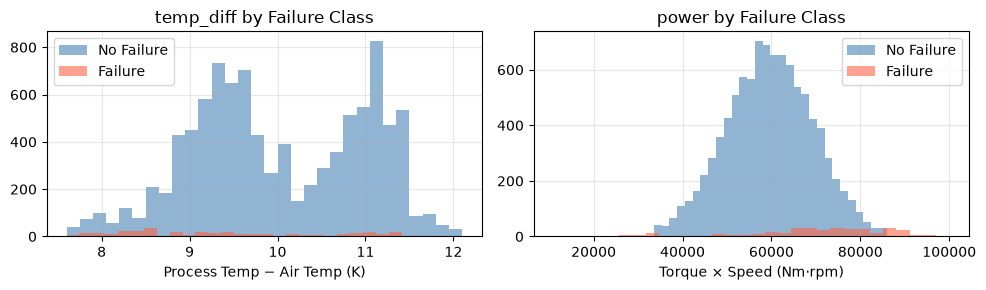

In [15]:
df['temp_diff'] = df['Process temperature [K]'] - df['Air temperature [K]']
df['power']     = df['Torque [Nm]'] * df['Rotational speed [rpm]']

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

for label, color in [(0, 'steelblue'), (1, 'tomato')]:
    subset = df[df['Machine failure'] == label]
    name = 'No Failure' if label == 0 else 'Failure'
    axes[0].hist(subset['temp_diff'], bins=30, alpha=0.6, color=color, label=name)
    axes[1].hist(subset['power'],     bins=30, alpha=0.6, color=color, label=name)

axes[0].set_title('temp_diff by Failure Class')
axes[0].set_xlabel('Process Temp − Air Temp (K)')
axes[0].legend()

axes[1].set_title('power by Failure Class')
axes[1].set_xlabel('Torque × Speed (Nm·rpm)')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 9. Key EDA Takeaways

- The dataset has **~3.4% failure rate** — heavily imbalanced. `class_weight="balanced"` is essential.
- **Tool wear** and **Torque** show the most visible separation between failure and non-failure classes.
- **Type L** machines show a slightly higher failure rate than M and H.
- `temp_diff` and `power` (engineered features) add signal beyond the raw sensor readings.
- No missing values or duplicate rows in this dataset.

> Next step: run `python -m src.train` to train the Random Forest model.